<a href="https://colab.research.google.com/github/habibiputrar/DeepLearning_B_2411531001_Habibi-Putra-Rizqullah/blob/main/Praktikum1/Praktikum1_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
#1. Load dataset
iris = load_iris()
X, y = iris.data, iris.target
X = StandardScaler().fit_transform(X)



In [ ]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Convert ke tensor
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

In [ ]:
# 2. Definisikan MLP
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
    def forward(self, x):
        return self.model(x)

In [ ]:
# 3. Inisialisasi model
model = MLP(4, 3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
# 4. Training loop
losses = []
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.3265
Epoch [20/100], Loss: 0.1098
Epoch [30/100], Loss: 0.0507
Epoch [40/100], Loss: 0.0397
Epoch [50/100], Loss: 0.0347
Epoch [60/100], Loss: 0.0309
Epoch [70/100], Loss: 0.0260
Epoch [80/100], Loss: 0.0208
Epoch [90/100], Loss: 0.0150
Epoch [100/100], Loss: 0.0099


In [ ]:
# 5. Evaluasi
with torch.no_grad():
    y_pred = torch.argmax(model(X_test), dim=1)
    acc = accuracy_score(y_test, y_pred)
    print(f'\nAkurasi Model: {acc:.4f}')


Akurasi Model: 1.0000


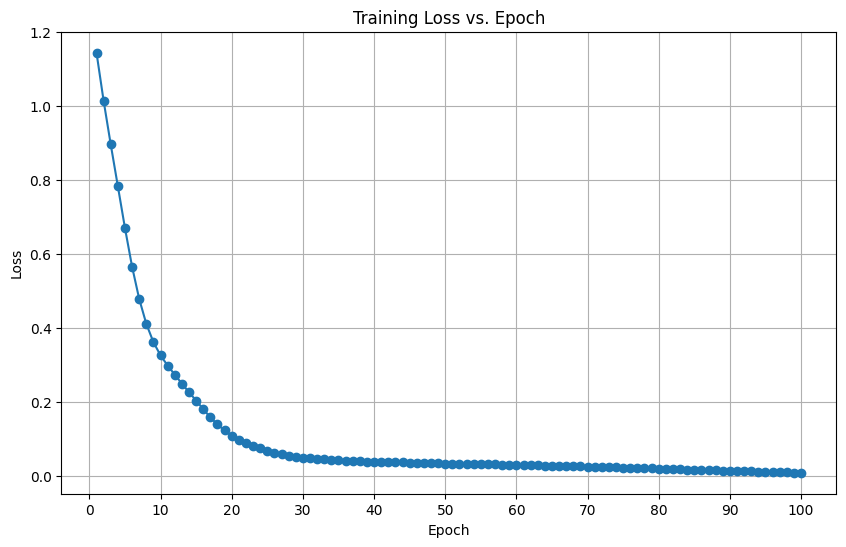

In [ ]:
# 6. Plot the loss curve
plt.figure(figsize=(10, 6))
epochs = range(1, len(losses) + 1)
plt.plot(epochs, losses, marker='o', linestyle='-')
plt.title('Training Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(0, len(losses) + 1, 10))
plt.show()
